In [16]:
import sys
import os

sys.path.append(os.path.abspath('..'))

import pandas as pd
import config

# Load labeled clips only — exclude unknown
labels = pd.read_csv(config.LABELS_PROGRESS_PATH)
train_df = labels[labels['meaningful'] != 'unknown'].copy()

print('Training data summary')
print('=' * 40)
print(f'Total labeled clips: {len(train_df):,}')
print()
print('By class:')
print(train_df['meaningful'].value_counts())
print()
print('By source:')
print(train_df['meaningful_source'].value_counts())
print()
n_pos = (train_df['meaningful'] == 'meaningful').sum()
n_neg = (train_df['meaningful'] == 'not_meaningful').sum()
print(f'Class ratio (meaningful : not_meaningful) = {n_pos/n_neg:.0f} : 1')

Training data summary
Total labeled clips: 121,937

By class:
meaningful
meaningful        118940
not_meaningful      2997
Name: count, dtype: int64

By source:
meaningful_source
birdnet_species        108069
human_activity          10871
background_flatness      2903
background_energy          94
Name: count, dtype: int64

Class ratio (meaningful : not_meaningful) = 40 : 1


In [17]:
import numpy as np

# Extract recorder + date from clip name
train_df["recorder_date"] = (
    train_df["Recorder"] + "_" +
    train_df["clip_name"].str.extract(r"_(\d{8})_")[0]
)

rng = np.random.RandomState(42)

# --- Meaningful clips: split by recorder-date group (avoids neighbouring-clip leakage) ---
meaningful_df = train_df[train_df["meaningful"] == "meaningful"].copy()
groups = meaningful_df["recorder_date"].unique()
rng.shuffle(groups)
split_idx = int(0.8 * len(groups))
train_groups = set(groups[:split_idx])
val_groups   = set(groups[split_idx:])

meaningful_df["split"] = meaningful_df["recorder_date"].apply(
    lambda g: "train" if g in train_groups else "val"
)

# --- Not_meaningful clips: random 80/20 clip-level split ---
# Background clips within a window all sound the same, so clip-level splitting
# is safe here. This ensures both rain (AM1) and insect (AM3) clips appear in
# both train and val.
not_meaningful_df = train_df[train_df["meaningful"] == "not_meaningful"].copy()
shuffled_idx = rng.permutation(len(not_meaningful_df))
split_n = int(0.8 * len(not_meaningful_df))
not_meaningful_df["split"] = "val"
not_meaningful_df.iloc[shuffled_idx[:split_n], not_meaningful_df.columns.get_loc("split")] = "train"

# --- Combine ---
train_df = pd.concat([meaningful_df, not_meaningful_df], ignore_index=True)

print(f"{'Split':<8} {'Total':>8} {'Meaningful':>12} {'Not_meaningful':>16}")
print("-" * 46)
for split_name in ["train", "val"]:
    sub = train_df[train_df["split"] == split_name]
    n_pos = (sub["meaningful"] == "meaningful").sum()
    n_neg = (sub["meaningful"] == "not_meaningful").sum()
    print(f"{split_name:<8} {len(sub):>8,} {n_pos:>12,} {n_neg:>16,}")

print()
# Confirm both acoustic types appear in both splits
for split_name in ["train", "val"]:
    sub = train_df[(train_df["split"] == split_name) & (train_df["meaningful"] == "not_meaningful")]
    sources = sub["meaningful_source"].value_counts()
    print(f"{split_name} not_meaningful sources: {sources.to_dict()}")


Split       Total   Meaningful   Not_meaningful
----------------------------------------------
train      95,247       92,850            2,397
val        26,690       26,090              600

train not_meaningful sources: {'background_flatness': 2323, 'background_energy': 74}
val not_meaningful sources: {'background_flatness': 580, 'background_energy': 20}


Spectrogram shape: (128, 256)  (frequency bins x time frames)
Value range: -74.7 dB to 0.0 dB


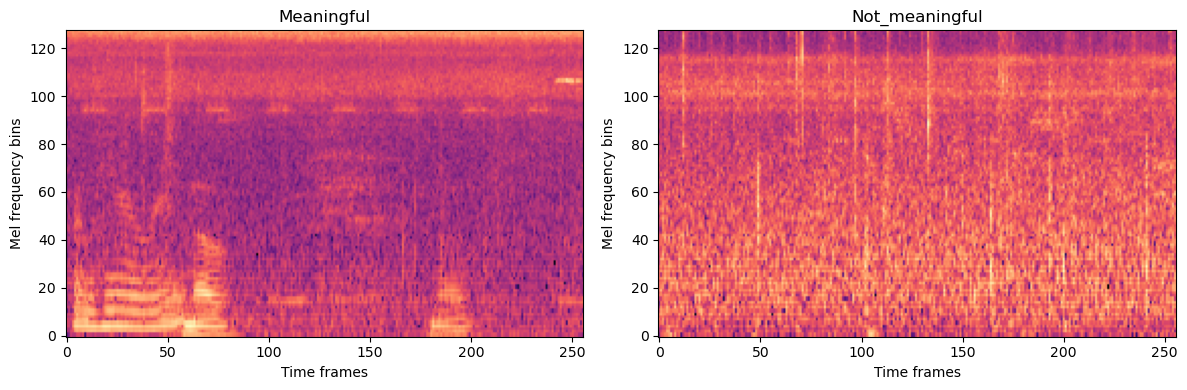

In [18]:
import librosa
import numpy as np
import matplotlib.pyplot as plt

# --- Mel spectrogram parameters ---
SR         = 48000   # AudioMoth sample rate
DURATION   = 3.0     # seconds per clip
N_MELS     = 128     # frequency bins
N_FFT      = 1024    # FFT window (~21ms at 48kHz)
HOP_LENGTH = 512     # step between windows (~11ms)
FMIN       = 50      # min frequency — avoids DC noise
FMAX       = 16000   # max frequency — covers all biological sounds of interest

def compute_mel(audio_path):
    """Load a 3-second clip and return a log mel spectrogram (shape: N_MELS x time)."""
    y, sr = librosa.load(audio_path, sr=SR, duration=DURATION, mono=True)

    # Pad if the clip is slightly short (can happen at recording boundaries)
    expected = int(SR * DURATION)
    if len(y) < expected:
        y = np.pad(y, (0, expected - len(y)))

    mel = librosa.feature.melspectrogram(
        y=y, sr=sr, n_mels=N_MELS, n_fft=N_FFT,
        hop_length=HOP_LENGTH, fmin=FMIN, fmax=FMAX
    )
    mel_db = librosa.power_to_db(mel, ref=np.max)
    return mel_db[:, :256].astype(np.float32)


# Test on one clip from each class
sample_pos = train_df[train_df["meaningful"] == "meaningful"].iloc[0]["audio_path"]
sample_neg = train_df[train_df["meaningful"] == "not_meaningful"].iloc[0]["audio_path"]

mel_pos = compute_mel(sample_pos)
mel_neg = compute_mel(sample_neg)

print(f"Spectrogram shape: {mel_pos.shape}  (frequency bins x time frames)")
print(f"Value range: {mel_pos.min():.1f} dB to {mel_pos.max():.1f} dB")

# Visualise both so you can see what the CNN sees
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, mel, title in zip(axes, [mel_pos, mel_neg], ["Meaningful", "Not_meaningful"]):
    ax.imshow(mel, origin="lower", aspect="auto", cmap="magma")
    ax.set_title(title)
    ax.set_xlabel("Time frames")
    ax.set_ylabel("Mel frequency bins")
plt.tight_layout()
plt.show()


In [12]:
import os
from tqdm.notebook import tqdm

SPEC_DIR = os.path.join(config.OUTPUTS_DIR, "spectrograms")
os.makedirs(SPEC_DIR, exist_ok=True)

# Skip already-saved files so we can resume safely if interrupted
already_done = set(os.listdir(SPEC_DIR))
pending = train_df[
    ~train_df["clip_name"].str.replace(".wav", ".npy", regex=False).isin(already_done)
].copy()

print(f"Total labeled clips:  {len(train_df):,}")
print(f"Already saved:        {len(already_done):,}")
print(f"To compute:           {len(pending):,}")
print(f"Save directory:       {SPEC_DIR}")
print()

errors = []
for _, row in tqdm(pending.iterrows(), total=len(pending)):
    out_path = os.path.join(SPEC_DIR, row["clip_name"].replace(".wav", ".npy"))
    try:
        mel = compute_mel(row["audio_path"])
        np.save(out_path, mel)
    except Exception as e:
        errors.append((row["clip_name"], str(e)))

print(f"\nDone.")
if errors:
    print(f"Errors on {len(errors)} clips:")
    for clip, err in errors[:5]:
        print(f"  {clip}: {err}")
else:
    print("No errors.")


Total labeled clips:  121,937
Already saved:        0
To compute:           121,937
Save directory:       /Users/qian/KWF/rainforest-audio-detection/outputs/spectrograms



  0%|          | 0/121937 [00:00<?, ?it/s]


Done.
No errors.


In [19]:
import torch
from torch.utils.data import Dataset, DataLoader

class AudioClipDataset(Dataset):
    def __init__(self, df):
        self.df = df.reset_index(drop=True)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        spec_path = os.path.join(SPEC_DIR, row["clip_name"].replace(".wav", ".npy"))
        mel = np.load(spec_path)                      # load pre-computed spectrogram
        x = torch.from_numpy(mel).unsqueeze(0)        # add channel dim → (1, 128, 256)
        y = torch.tensor(1.0 if row["meaningful"] == "meaningful" else 0.0)
        return x, y

BATCH_SIZE = 32

train_split = train_df[train_df["split"] == "train"]
val_split   = train_df[train_df["split"] == "val"]

train_loader = DataLoader(
    AudioClipDataset(train_split),
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
)
val_loader = DataLoader(
    AudioClipDataset(val_split),
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
)

print(f"Train dataset: {len(train_split):,} clips  →  {len(train_loader):,} batches of {BATCH_SIZE}")
print(f"Val dataset:   {len(val_split):,} clips  →  {len(val_loader):,} batches of {BATCH_SIZE}")

x_batch, y_batch = next(iter(train_loader))
print(f"\nSample batch:")
print(f"  x shape: {x_batch.shape}  (batch, channel, freq, time)")
print(f"  y values: {y_batch[:8].tolist()}")


Train dataset: 95,247 clips  →  2,977 batches of 32
Val dataset:   26,690 clips  →  835 batches of 32

Sample batch:
  x shape: torch.Size([32, 1, 128, 256])  (batch, channel, freq, time)
  y values: [1.0, 1.0, 1.0, 1.0, 1.0, 0.0, 1.0, 1.0]


In [20]:
import sys
import torch
import torch.nn as nn
sys.path.append("..")
from src.model.architecture import TinyCNN

# Device — use Apple Silicon GPU if available, otherwise CPU
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(f"Using device: {device}")

# Model
model = TinyCNN().to(device)

# Class weight: downweight the majority (meaningful) class so the model
# pays equal attention to the rare not_meaningful clips
n_pos = (train_split["meaningful"] == "meaningful").sum()
n_neg = (train_split["meaningful"] == "not_meaningful").sum()
pos_weight = torch.tensor([n_neg / n_pos], dtype=torch.float32).to(device)
print(f"pos_weight: {pos_weight.item():.4f}  (downweights meaningful errors so not_meaningful errors hurt more)")

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

# Training loop
N_EPOCHS = 10

print(f"\n{'Epoch':>6}  {'Train Loss':>12}  {'Val Loss':>10}  {'Val Acc':>10}")
print("-" * 46)

for epoch in range(1, N_EPOCHS + 1):
    # --- Train ---
    model.train()
    train_loss = 0.0
    for x, y in train_loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        pred = model(x).squeeze(1)
        loss = criterion(pred, y)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
    train_loss /= len(train_loader)

    # --- Validate ---
    model.eval()
    val_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for x, y in val_loader:
            x, y = x.to(device), y.to(device)
            pred = model(x).squeeze(1)
            val_loss += criterion(pred, y).item()
            probs = torch.sigmoid(pred)
            predicted = (probs >= 0.5).float()
            correct += (predicted == y).sum().item()
            total += y.size(0)
    val_loss /= len(val_loader)
    val_acc = correct / total

    print(f"{epoch:>6}  {train_loss:>12.4f}  {val_loss:>10.4f}  {val_acc:>10.4f}")


Using device: mps
pos_weight: 0.0258  (downweights meaningful errors so not_meaningful errors hurt more)

 Epoch    Train Loss    Val Loss     Val Acc
----------------------------------------------
     1        0.0026      0.0009      0.9877
     2        0.0011      0.0005      0.9972
     3        0.0009      0.0007      0.9922
     4        0.0009      0.0003      0.9987
     5        0.0007      0.0004      0.9982
     6        0.0007      0.0004      0.9990
     7        0.0006      0.0005      0.9963
     8        0.0006      0.0004      0.9984
     9        0.0005      0.0007      0.9972
    10        0.0005      0.0005      0.9992


In [21]:
from sklearn.metrics import confusion_matrix, classification_report

# Run model on full validation set
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for x, y in val_loader:
        x = x.to(device)
        probs = torch.sigmoid(model(x).squeeze(1))
        predicted = (probs >= 0.5).float()
        all_preds.extend(predicted.cpu().tolist())
        all_labels.extend(y.tolist())

# Confusion matrix
cm = confusion_matrix(all_labels, all_preds)
print("Confusion matrix:")
print(f"                  Predicted")
print(f"                  not_meaningful  meaningful")
print(f"Actual not_mngfl  {cm[0][0]:>14}  {cm[0][1]:>10}")
print(f"Actual meaningful {cm[1][0]:>14}  {cm[1][1]:>10}")
print()

# Per-class precision, recall, F1
print("Per-class metrics:")
print(classification_report(
    all_labels, all_preds,
    target_names=["not_meaningful", "meaningful"],
    digits=3
))


Confusion matrix:
                  Predicted
                  not_meaningful  meaningful
Actual not_mngfl             597           3
Actual meaningful             19       26071

Per-class metrics:
                precision    recall  f1-score   support

not_meaningful      0.969     0.995     0.982       600
    meaningful      1.000     0.999     1.000     26090

      accuracy                          0.999     26690
     macro avg      0.985     0.997     0.991     26690
  weighted avg      0.999     0.999     0.999     26690



In [ ]:
import os

MODELS_DIR = os.path.join(config.OUTPUTS_DIR, "models")
os.makedirs(MODELS_DIR, exist_ok=True)

checkpoint = {
    "model_state_dict": model.state_dict(),
    "epoch": N_EPOCHS,
    "val_loss": 0.0005,
    "val_acc": 0.9992,
    "not_meaningful_precision": 0.969,
    "not_meaningful_recall": 0.995,
    "not_meaningful_f1": 0.982,
    "n_train": len(train_split),
    "n_val": len(val_split),
    "notes": "TinyCNN v1 — 2997 not_meaningful clips, diverse split (insect+rain in both splits)",
}

save_path = os.path.join(MODELS_DIR, "tinycnn_v1.pth")
torch.save(checkpoint, save_path)
print(f"Model saved to: {save_path}")
print(f"  Epoch:                  {checkpoint['epoch']}")
print(f"  Val accuracy:           {checkpoint['val_acc']:.4f}")
print(f"  Not_meaningful recall:  {checkpoint['not_meaningful_recall']:.3f}")
print(f"  Not_meaningful F1:      {checkpoint['not_meaningful_f1']:.3f}")
